In [82]:
import os
import gc
import time
import gseapy as gp
import textwrap

from pathlib import Path
from collections import Counter
from functools import reduce

import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind

import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
from matplotlib.lines import Line2D
import matplotlib as mpl

from upsetplot import from_contents, generate_counts, UpSet, plot, from_indicators
from pycirclize import Circos

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [5]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [6]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29
}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [7]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [8]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [9]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [10]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)][['assay']].value_counts()

assay                                     
Radial Glia SOX2+VIM+FABP7+                   24
Proliferative Radial Glia SOX2+HES6+TOP2A+     3
IPC EOMES+NEUROG2+PAX6+                        1
Mesenchymal-like cells VIM+VCAN+SPARC+         1
Mixed Neurons FGF12+GRIN2B+CAMK2B+             1
Name: count, dtype: int64

In [11]:
dge_idiopathic

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,significant_fdr
0,A1BG,Mesenchymal-like cells VIM+VCAN+SPARC+,0.355352,0.571959,0.621290,0.534409,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | A1BG,0.701697,False
1,A1BG,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.353854,0.634559,2.133534,0.032881,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | A1BG,0.128893,False
2,A1BG,Radial Glia SOX2+PAX6+FABP7+,0.309485,0.318147,0.972774,0.330666,1,FE,Radial Glia SOX2+PAX6+FABP7+ | A1BG,0.539401,False
3,A1BG-AS1,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.306088,0.332704,-0.920000,0.357573,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | A1BG-AS1,0.549093,False
4,AAAS,Mesenchymal-like cells VIM+VCAN+SPARC+,0.109481,0.229449,0.477147,0.633257,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | AAAS,0.776476,False
...,...,...,...,...,...,...,...,...,...,...,...
35225,ZZEF1,Mesenchymal-like cells VIM+VCAN+SPARC+,0.216788,0.181727,1.192933,0.232896,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | ZZEF1,0.414046,False
35226,ZZZ3,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.380565,0.176595,-2.155013,0.031161,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+ | ZZZ3,0.102045,False
35227,ZZZ3,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.090411,0.296172,0.305267,0.760163,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+ | ZZZ3,0.886567,False
35228,ZZZ3,Radial Glia SOX2+PAX6+FABP7+,-0.257875,0.273861,-0.941627,0.346384,1,FE,Radial Glia SOX2+PAX6+FABP7+ | ZZZ3,0.555012,False


In [12]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [13]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [14]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [15]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [16]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    194
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+     50
Hindbrain Neurons NR2F2+PBX3+LHX1+              45
Proliferative Radial Glia SOX2+HES6+TOP2A+      39
Radial Glia SOX2+PAX6+FABP7+                     7
Mixed Neurons FGF12+GRIN2B+CAMK2B+               5
Name: count, dtype: int64

In [17]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     3
Name: count, dtype: int64

In [18]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    300
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     18
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [19]:
## Check Overlap Between Directionally Consistent MetaAnalyzed DataFrames ##

df_22q11_to_merge = dc_significant_22q11_df_logfc.copy()
df_22q11_to_merge.columns = [i+'_22q11' for i in df_22q11_to_merge.columns]

df_nrxn1_to_merge = dc_significant_nrxn1_df_logfc.copy()
df_nrxn1_to_merge.columns = [i+'_nrxn1' for i in df_nrxn1_to_merge.columns]

df_idiopathic_to_merge = dc_significant_idiopathic_df_logfc.copy()
df_idiopathic_to_merge.columns = [i+'_idiopathic' for i in dc_significant_idiopathic_df_logfc.columns]

df_22q11_nrxn1 = df_22q11_to_merge.merge(df_nrxn1_to_merge, 
                                         right_on=['ID_nrxn1', 'assay_nrxn1'], 
                                         left_on=['ID_22q11', 'assay_22q11'])

df_22q11_idiopathic = df_22q11_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_22q11', 'assay_22q11'])

df_nrxn1_idiopathic = df_nrxn1_to_merge.merge(df_idiopathic_to_merge, 
                                              right_on=['ID_idiopathic', 'assay_idiopathic'], 
                                              left_on=['ID_nrxn1', 'assay_nrxn1'])

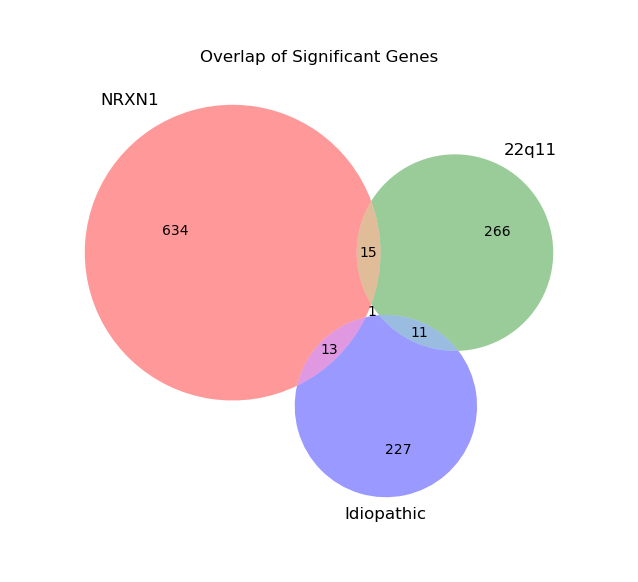

In [20]:
# ## Venn Diagram Of Overlap CellType Agonstic ##

# # Convert your lists to sets
# dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
# dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
# dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# # --- Venn diagram for all three lists ---
# plt.figure(figsize=(8, 6))
# venn3([dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
#       set_labels=('NRXN1', '22q11', 'Idiopathic'))
# plt.title("Overlap of Significant Genes")
# plt.show()

In [21]:
# dge_22q11_set.intersection(dge_idiopathic_set).intersection(dge_nrxn1_set) #.intersection(dge_3q29)

{'WWC2'}

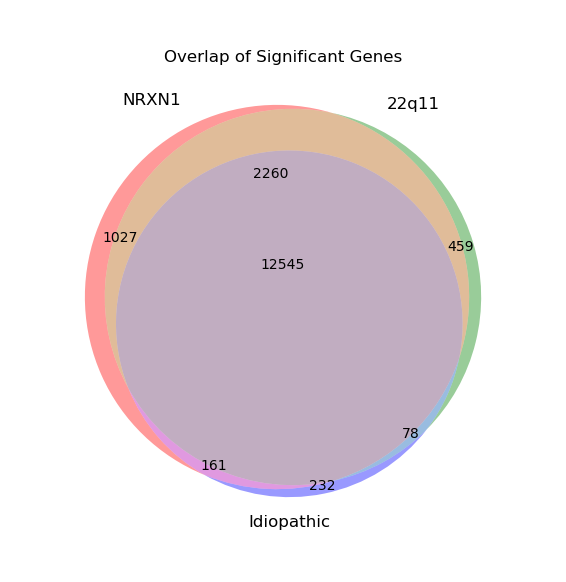

In [22]:
# ## Venn Diagram Of Overlap CellType Agonstic ##

# ## No Directional Consistency Demands ##

# # --- Venn diagram for all three lists ---
# plt.figure(figsize=(8, 6))
# venn3([set(dge_nrxn1['ID']), set(dge_22q11['ID']), set(dge_idiopathic['ID'])],
#       set_labels=('NRXN1', '22q11', 'Idiopathic'))
# plt.title("Overlap of Significant Genes")
# plt.show()

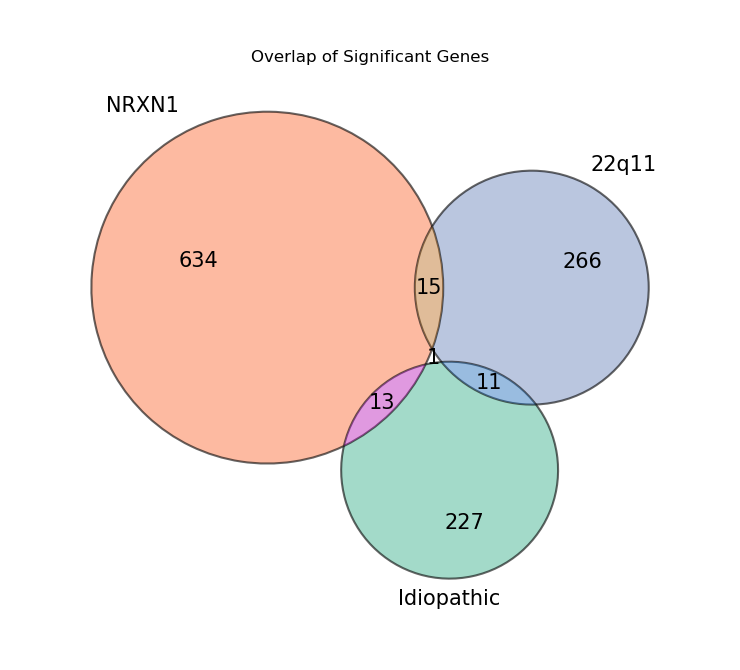

In [23]:
# # # Convert to sets
# dge_nrxn1_set = set(dc_significant_nrxn1_df_logfc['ID'])
# dge_22q11_set = set(dc_significant_22q11_df_logfc['ID'])
# dge_idiopathic_set = set(dc_significant_idiopathic_df_logfc['ID'])

# # Custom colors
# COLORS = {
#     "NRXN1": "#fc8d62ff",
#     "22q11": "#8da0cbff",
#     "Idiopathic": "#66c2a5ff"
# }
   
    
# plt.figure(figsize=(8, 6))

# v = venn3(
#     [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
#     set_labels=('NRXN1', '22q11', 'Idiopathic')
# )

# # MAIN SET COLORS + EDGES
# v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
# v.get_patch_by_id('100').set_alpha(0.6)
# v.get_patch_by_id('100').set_edgecolor('black')
# v.get_patch_by_id('100').set_linewidth(1.5)

# v.get_patch_by_id('010').set_color(COLORS["22q11"])
# v.get_patch_by_id('010').set_alpha(0.6)
# v.get_patch_by_id('010').set_edgecolor('black')
# v.get_patch_by_id('010').set_linewidth(1.5)

# v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
# v.get_patch_by_id('001').set_alpha(0.6)
# v.get_patch_by_id('001').set_edgecolor('black')
# v.get_patch_by_id('001').set_linewidth(1.5)

# # LABEL STYLING

# for text in v.set_labels:
#     if text:
#         text.set_fontsize(15)

# for text in v.subset_labels:
#     if text:
#         text.set_fontsize(15)

# plt.title("Overlap of Significant Genes")
# plt.tight_layout()
# plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
# plt.show()

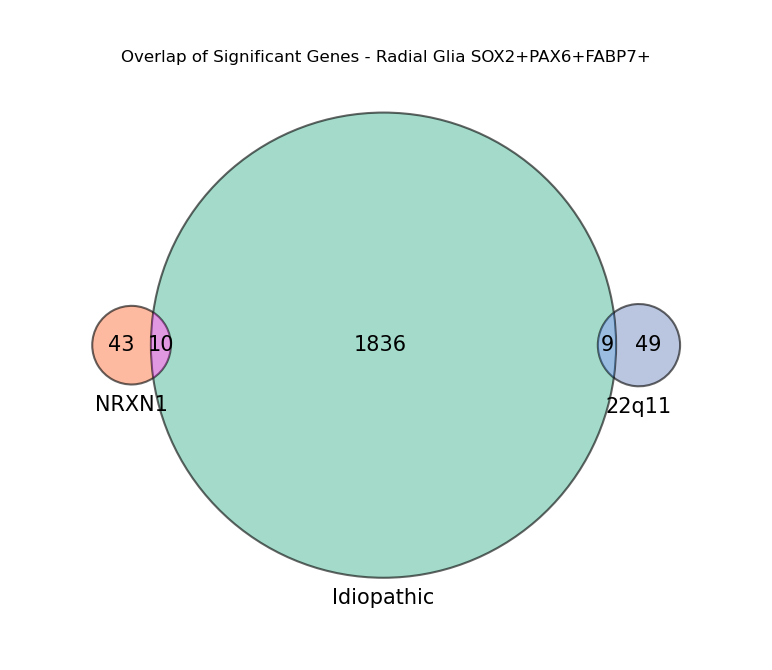

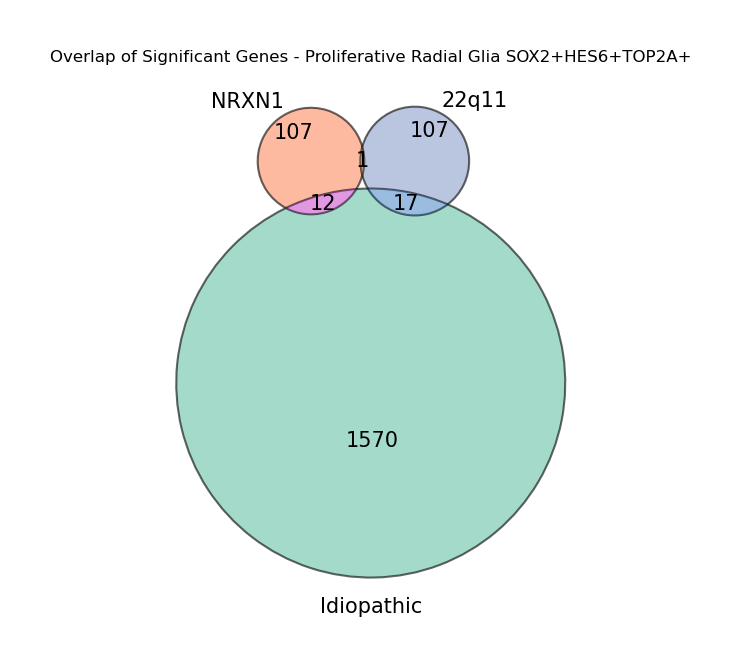

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")
/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


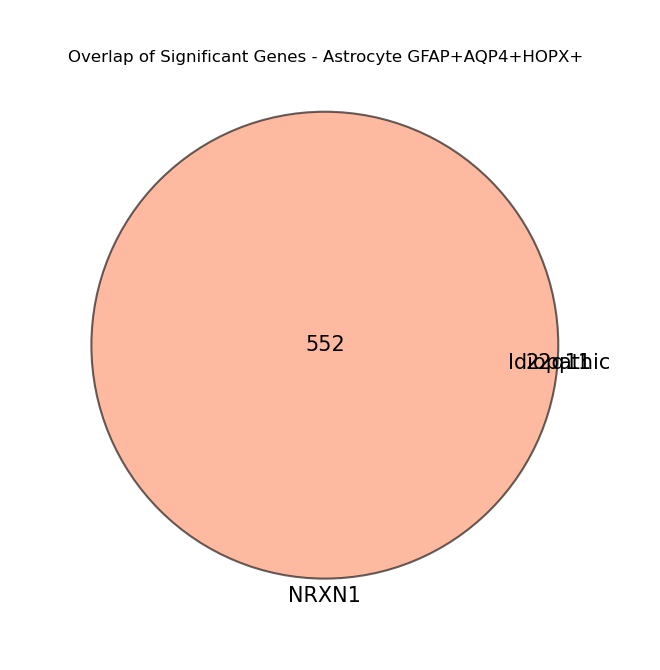

/home/deepak/pixi_envs/scanpy/.pixi/envs/default/lib/python3.12/site-packages/matplotlib_venn/layout/venn3/pairwise.py:103: UserWarning: Circle A has zero area.
  warnings.warn("Circle A has zero area.")


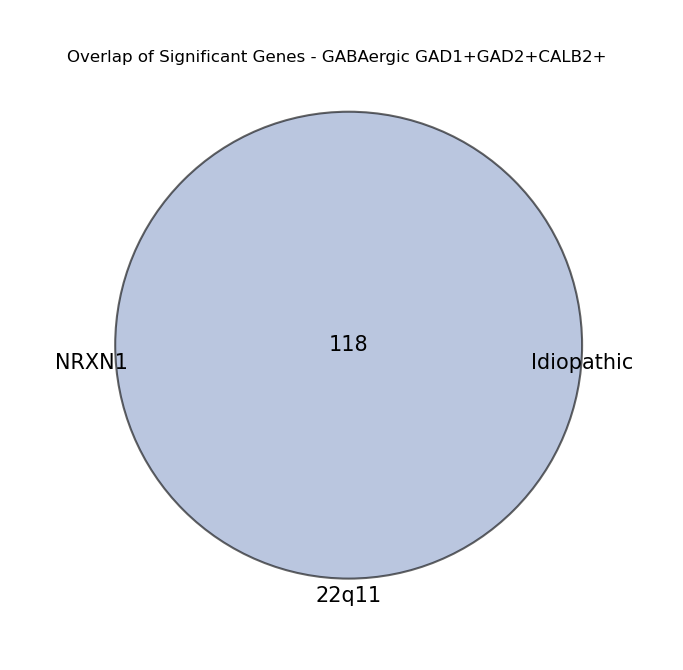

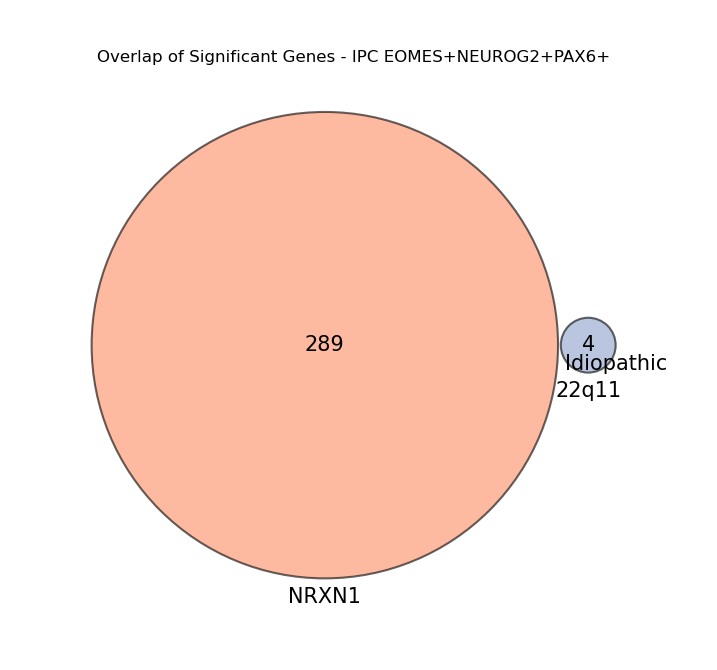

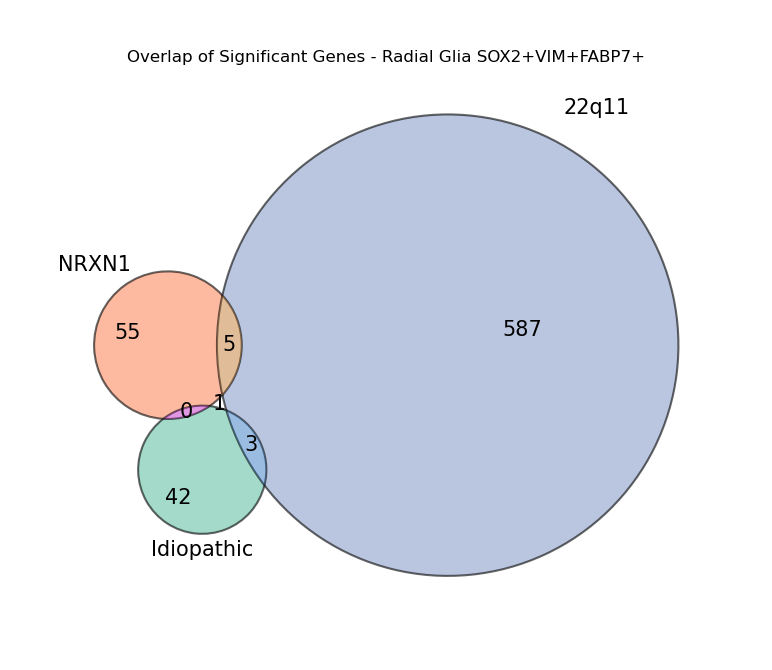

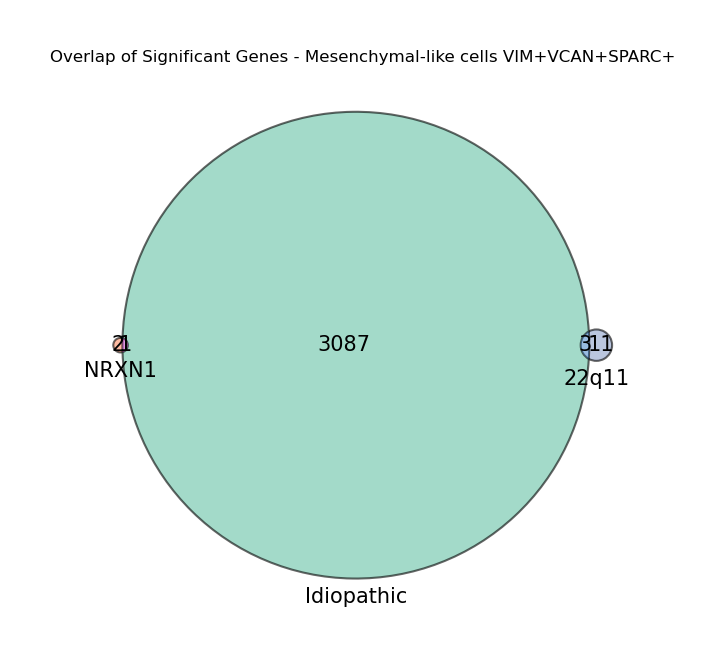

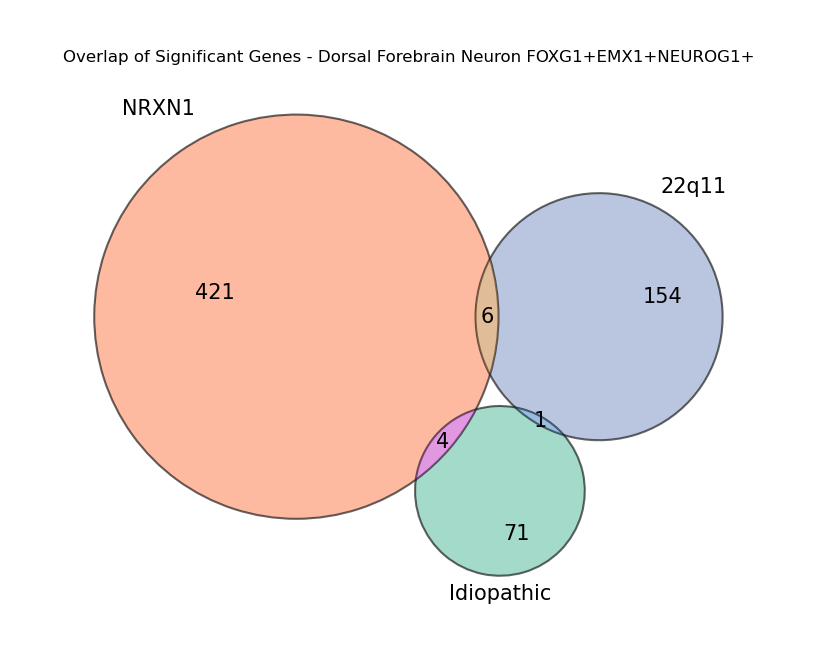

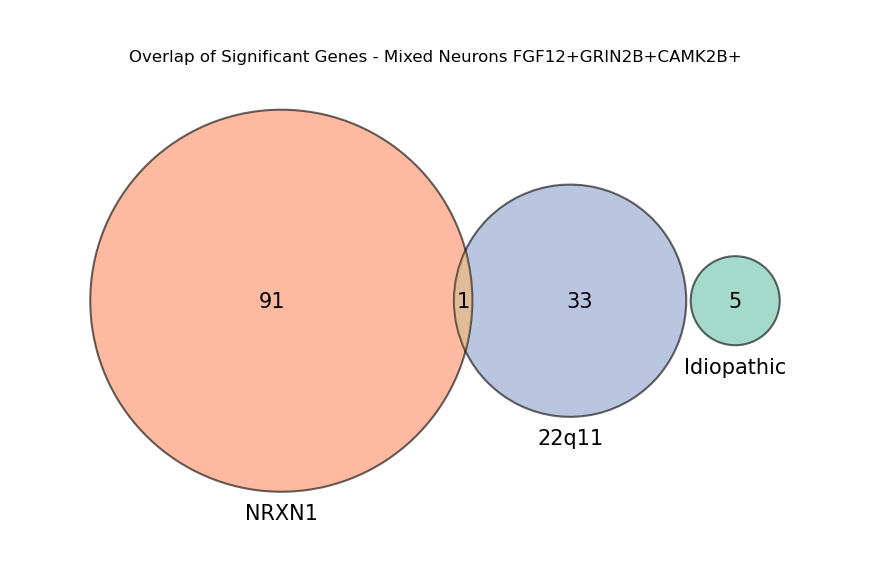

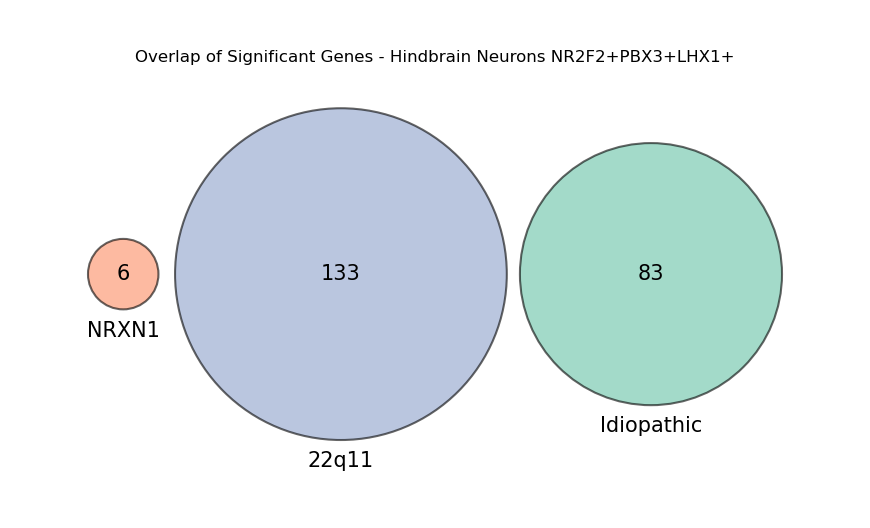

In [24]:
# # Convert to sets

# celltypes = set(dge_idiopathic['assay']).union(set(dge_22q11['assay'])).union(set(dge_nrxn1['assay']))

# # Custom colors
# COLORS = {"NRXN1": "#fc8d62ff", "22q11": "#8da0cbff", "Idiopathic": "#66c2a5ff"}
# def safe_style_patch(v, pid, color):
#     patch = v.get_patch_by_id(pid)
#     if patch is not None:
#         patch.set_color(color)
#         patch.set_alpha(0.6)
#         patch.set_edgecolor('black')
#         patch.set_linewidth(1.5)

# # -----------------------------
# # LOOP OVER CELLTYPES
# # -----------------------------
# for celltype in celltypes:

#     idiopathic_filter = set(
#         dge_idiopathic[(dge_idiopathic['assay'] == celltype) & dge_idiopathic['significant_fdr']]['ID']
#     )
#     x22q11_filter = set(
#         dge_22q11[(dge_22q11['assay'] == celltype) & dge_22q11['significant_fdr']]['ID']
#     )
#     nrxn1_filter = set(
#         dge_nrxn1[(dge_nrxn1['assay'] == celltype) & dge_nrxn1['significant_fdr']]['ID']
#     )

#     plt.figure(figsize=(8, 6))

#     v = venn3(
#         [nrxn1_filter, x22q11_filter, idiopathic_filter],
#         set_labels=('NRXN1', '22q11', 'Idiopathic')
#     )

#     # -----------------------------
#     # STYLE SET REGIONS SAFELY
#     # -----------------------------
#     safe_style_patch(v, '100', COLORS["NRXN1"])
#     safe_style_patch(v, '010', COLORS["22q11"])
#     safe_style_patch(v, '001', COLORS["Idiopathic"])

#     # -----------------------------
#     # STYLE LABELS SAFELY
#     # -----------------------------
#     if v.set_labels:
#         for text in v.set_labels:
#             if text:
#                 text.set_fontsize(15)

#     if v.subset_labels:
#         for text in v.subset_labels:
#             if text:
#                 text.set_fontsize(15)

#     plt.title(f"Overlap of Significant Genes - {celltype}")
#     plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_{celltype}_venn.svg", bbox_inches='tight')
#     plt.tight_layout()
#     plt.show()

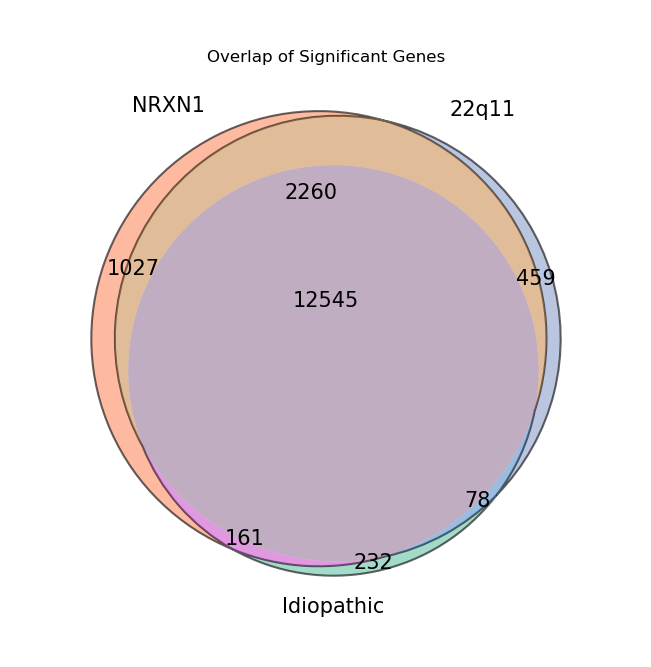

In [25]:
# ## Without DC ##

# dge_nrxn1_set = set(dge_nrxn1['ID'])
# dge_22q11_set = set(dge_22q11['ID'])
# dge_idiopathic_set = set(dge_idiopathic['ID'])

# # Custom colors
# COLORS = {
#     "NRXN1": "#fc8d62ff",
#     "22q11": "#8da0cbff",
#     "Idiopathic": "#66c2a5ff"
# }

# plt.figure(figsize=(8, 6))

# v = venn3(
#     [dge_nrxn1_set, dge_22q11_set, dge_idiopathic_set],
#     set_labels=('NRXN1', '22q11', 'Idiopathic')
# )

# # =====================================================
# # MAIN SET COLORS + EDGES
# # =====================================================

# v.get_patch_by_id('100').set_color(COLORS["NRXN1"])
# v.get_patch_by_id('100').set_alpha(0.6)
# v.get_patch_by_id('100').set_edgecolor('black')
# v.get_patch_by_id('100').set_linewidth(1.5)

# v.get_patch_by_id('010').set_color(COLORS["22q11"])
# v.get_patch_by_id('010').set_alpha(0.6)
# v.get_patch_by_id('010').set_edgecolor('black')
# v.get_patch_by_id('010').set_linewidth(1.5)

# v.get_patch_by_id('001').set_color(COLORS["Idiopathic"])
# v.get_patch_by_id('001').set_alpha(0.6)
# v.get_patch_by_id('001').set_edgecolor('black')
# v.get_patch_by_id('001').set_linewidth(1.5)

# # =====================================================
# # LABEL STYLING (optional polish)
# # =====================================================

# for text in v.set_labels:
#     if text:
#         text.set_fontsize(15)

# for text in v.subset_labels:
#     if text:
#         text.set_fontsize(15)

# plt.title("Overlap of Significant Genes")
# plt.tight_layout()
# plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/Fig_4_all_celltypes_venn.svg", bbox_inches='tight')
# plt.show()

In [30]:
significant_all = pd.concat([dge_idiopathic.assign(group='Idiopathic Schizophrenia'),
                                dge_nrxn1.assign(group='NRXN1del'), 
                                dge_22q11.assign(group='22q11.2del')], axis=0)

significant_all = significant_all[significant_all['significant_fdr']]

In [39]:
significant_all_rg_pax6 = significant_all[significant_all['assay'] == 'Radial Glia SOX2+PAX6+FABP7+']
significant_all_prg = significant_all[significant_all['assay'] == 'Proliferative Radial Glia SOX2+HES6+TOP2A+']
significant_all_rg_vim = significant_all[significant_all['assay'] == 'Radial Glia SOX2+VIM+FABP7+']
significant_all_ipc = significant_all[significant_all['assay'] == 'IPC EOMES+NEUROG2+PAX6+']
significant_all_dorsal = significant_all[significant_all['assay'] == 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']
significant_all_mixed = significant_all[significant_all['assay'] == 'Mixed Neurons FGF12+GRIN2B+CAMK2B+']
significant_all_hindbrain = significant_all[significant_all['assay'] == 'Hindbrain Neurons NR2F2+PBX3+LHX1+']
significant_all_mc = significant_all[significant_all['assay'] == 'Mesenchymal-like cells VIM+VCAN+SPARC+']
significant_all_astro = significant_all[significant_all['assay'] == 'Astrocyte GFAP+AQP4+HOPX+']
significant_all_gaba = significant_all[significant_all['assay'] == 'GABAergic GAD1+GAD2+CALB2+']

In [57]:
def run_enrichr_for_groups(gene_sets, gene_set_db='KEGG_2016'):
    
    results = []

    for (disease, celltype), genes in gene_sets.items():

        if len(genes) < 5:   # avoid tiny unstable sets
            continue

        time.sleep(1.5)  

        enr = gp.enrichr(
            gene_list=genes,
            gene_sets=gene_set_db,
            organism='hs',
            outdir=None,
            no_plot=True
        )

        df = enr.results.copy()
        df['disease'] = disease
        df['celltype'] = celltype

        results.append(df)

    return pd.concat(results, ignore_index=True)

In [58]:
gene_sets = significant_all.groupby(['group', 'assay'])['ID'].apply(list)

enrich_df = run_enrichr_for_groups(gene_sets, gene_set_db='GO_Molecular_Function_2026')

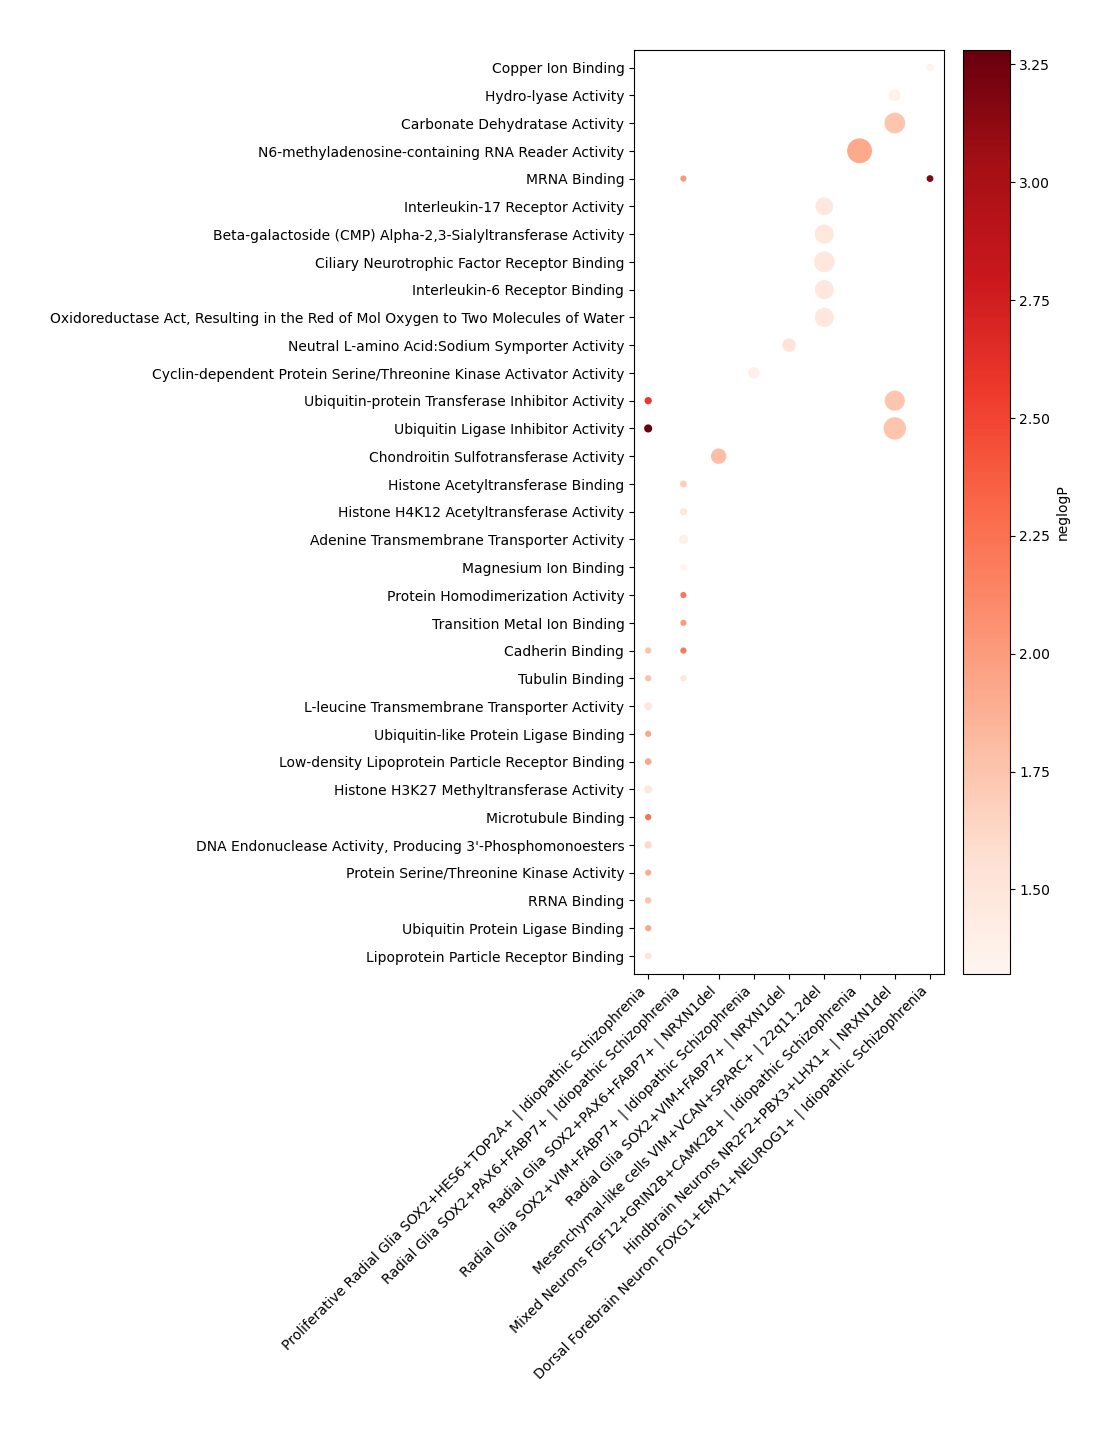

In [59]:
# ## Individual Signatures GO Plots ## 

# plot_df = enrich_df.copy()
# plot_df = plot_df[plot_df['Adjusted P-value'] < 0.05].copy()

# plot_df['neglogp'] = -np.log10(plot_df['Adjusted P-value'].astype('float'))
# plot_df['group'] = plot_df['celltype'] + " | " + plot_df['disease']

# # -----------------------------
# # AGGREGATE
# # -----------------------------
# agg = plot_df.groupby(['Term', 'group']).agg({
#     'neglogp': 'max',
#     'Combined Score': 'mean',
#     'Odds Ratio': 'mean'
# }).reset_index()

# plot_long = agg.copy()

# # -----------------------------
# # ORDER GROUPS (CELLTYPE FIRST)
# # -----------------------------
# plot_long['celltype'] = plot_long['group'].str.split(" \\| ").str[0]

# unique_celltypes = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
#                     'Radial Glia SOX2+VIM+FABP7+', 'Mesenchymal-like cells VIM+VCAN+SPARC+',
#                     'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
#                     'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+']

# group_order = []
# for ct in unique_celltypes:
#     sub = sorted([g for g in plot_long['group'].unique() if g.startswith(ct + " | ")])
#     group_order.extend(sub)

# plot_long['group'] = pd.Categorical(plot_long['group'], categories=group_order, ordered=True)

# # map x positions for ordering signal
# group_to_num = {g: i for i, g in enumerate(group_order)}
# plot_long['x_pos'] = plot_long['group'].map(group_to_num)

# # -----------------------------
# # TERM ORDER (CREATES DIAGONAL STRUCTURE)
# # -----------------------------

# plot_long['Term'] = plot_long['Term'].str.replace(r'\s*\(GO.*$', '', regex=True).str.strip()

# term_order = (
#     plot_long
#     .groupby('Term')
#     .apply(lambda d: np.average(d['x_pos'], weights=d['neglogp']))
#     .sort_values()
#     .index
#     .tolist())

# plot_long['Term'] = pd.Categorical(plot_long['Term'], categories=term_order, ordered=True)

# plot_long['neglogp'] = plot_long['neglogp'].astype('float')

# # -----------------------------
# # PLOT
# # -----------------------------

# plot_long['Term'] = plot_long['Term'].cat.remove_unused_categories()

# df = plot_long.copy()

# # ensure numeric codes for categories
# x = df['group'].astype('category').cat.codes
# y = df['Term'].astype('category').cat.codes

# norm = mpl.colors.Normalize(
#     vmin=df['neglogp'].min(),
#     vmax=df['neglogp'].max()
# )

# plt.figure(figsize=(5, 12))

# plt.scatter(
#     x,
#     y,
#     c=df['neglogp'],
#     cmap='Reds',
#     norm=norm,
#     s=20 + (df['Odds Ratio'] - df['Odds Ratio'].min()) /
#            (df['Odds Ratio'].max() - df['Odds Ratio'].min()) * 300,
#     edgecolors='none'
# )

# plt.xticks(
#     range(len(df['group'].astype('category').cat.categories)),
#     df['group'].astype('category').cat.categories,
#     rotation=45,
#     ha='right'
# )

# plt.yticks(
#     range(len(df['Term'].astype('category').cat.categories)),
#     df['Term'].astype('category').cat.categories
# )

# plt.colorbar(label='neglogP')
# plt.margins(y=0.02)
# plt.show()

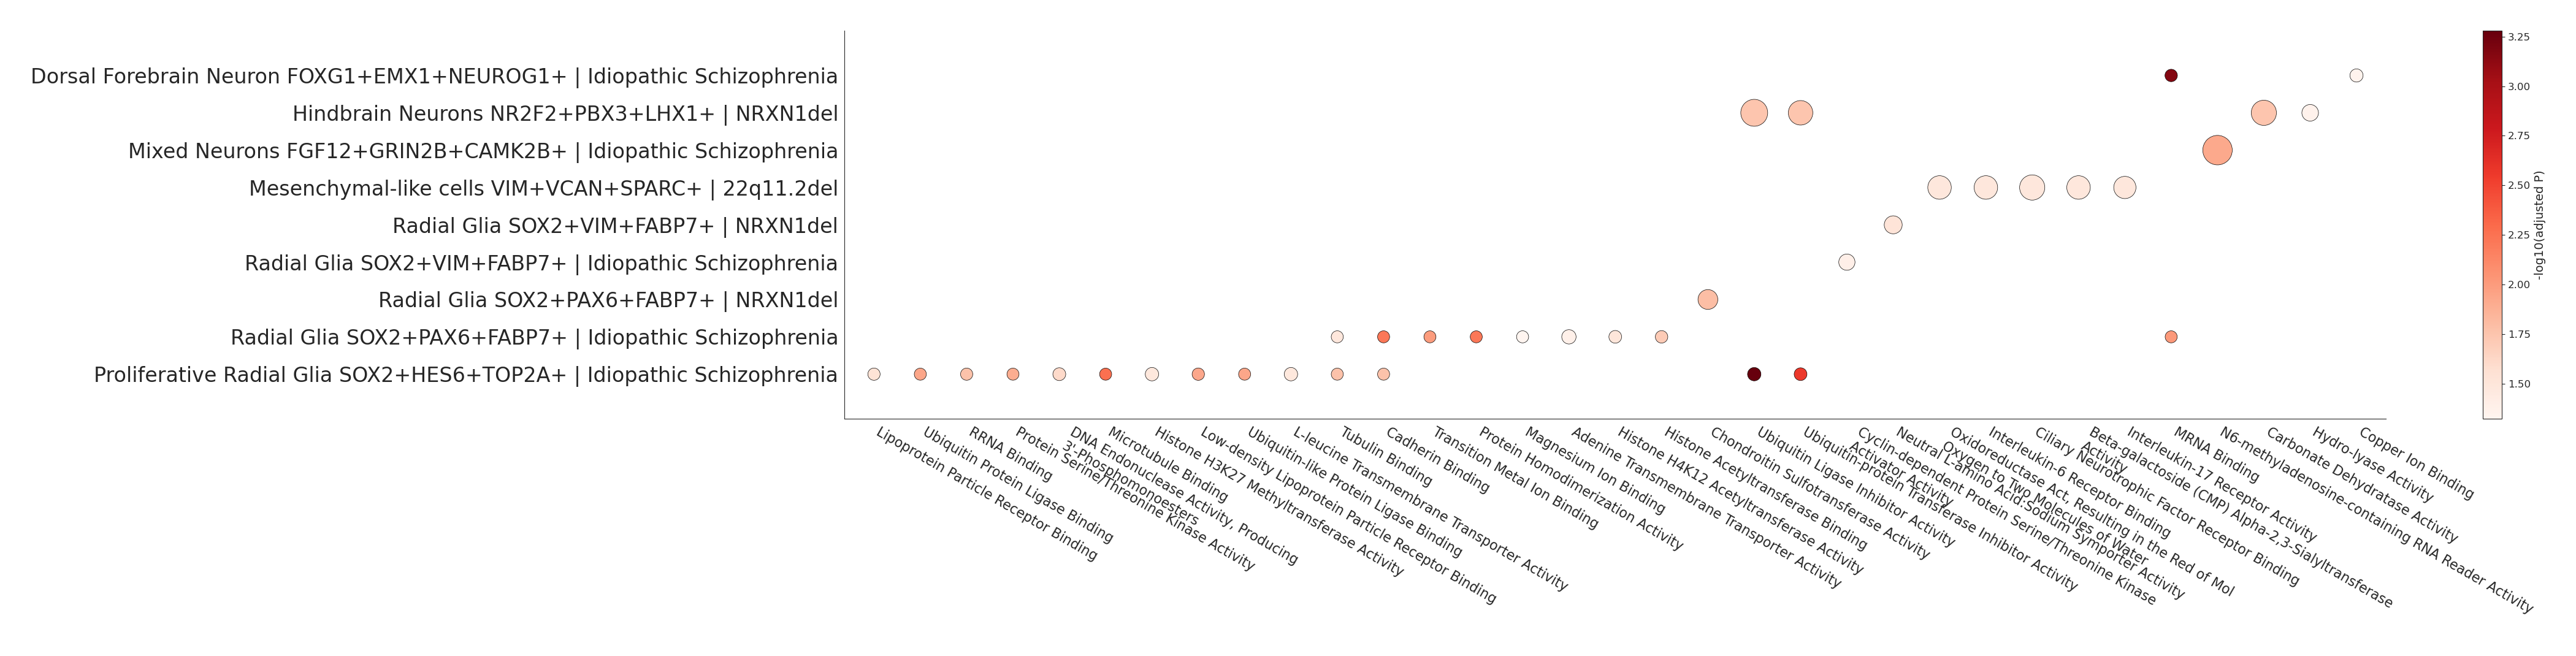

In [97]:
# -----------------------------
# WRAP GO TERMS (WITHOUT CHANGING ORDER)
# -----------------------------
ordered_terms = plot_long["Term"].cat.categories

wrapped_labels = [
    "\n".join(textwrap.wrap(term, width=50))
    for term in ordered_terms
]

# numeric x positions preserve the learned ordering
plot_long["x"] = plot_long["Term"].cat.codes

# -----------------------------
# PLOT
# -----------------------------
df = plot_long.copy()

x = df["x"]
y = df["group"].cat.codes

norm = mpl.colors.Normalize(
    vmin=df['neglogp'].min(),
    vmax=df['neglogp'].max()
)

fig, ax = plt.subplots(figsize=(45, 10))

sc = ax.scatter(
    x,
    y,
    c=df['neglogp'],
    cmap='Reds',
    norm=norm,
    s=200 + (
        (df['Odds Ratio'] - df['Odds Ratio'].min()) /
        (df['Odds Ratio'].max() - df['Odds Ratio'].min())
    ) * 1000,
    edgecolors='black',
    linewidths=0.5
)

# Y-axis (groups)
ax.set_yticks(
    range(len(df['group'].cat.categories))
)
ax.set_yticklabels(
    df['group'].cat.categories
)

# X-axis (ordered GO terms with wrapped labels)
ax.set_xticks(range(len(ordered_terms)))
ax.set_xticklabels(
    wrapped_labels,
    rotation=-30,
    ha='left'
)

# Styling
ax.set_ylabel("")
ax.set_xlabel("")

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=24)

for label in ax.get_yticklabels():
    label.set_fontweight('medium')

ax.margins(x=0.02)
ax.margins(y=0.15)

sns.despine(top=True, right=True, ax=ax)

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("-log10(adjusted P)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

plt.savefig(
    "/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_Dot_Plot.svg",
    bbox_inches="tight"
)

plt.show()

In [67]:
## Find Duplicates in Dorsal DGE ##

dc_significant_all_dorsal[dc_significant_all_dorsal['ID'].duplicated(keep=False)]

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,assay_ID,p.adjusted,...,logFC_sawada,logFC_notaras,directionally_consistent,mean_logFC,group,logFC_sebastian,logFC_fernando,logFC_rao,logFC_shin,logFC_walsh
277,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.381210,0.100870,3.779235,1.573109e-04,2,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.008815,...,NaN,NaN,True,0.317700,NRXN1del,0.117488,0.517913,NaN,NaN,NaN
159,ESS2,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.861508,0.117751,-7.316366,2.547755e-13,3,FE,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+ | ...,0.0,...,NaN,NaN,True,-0.792062,22q11.2del,NaN,NaN,-0.93121,-0.482282,-0.962693


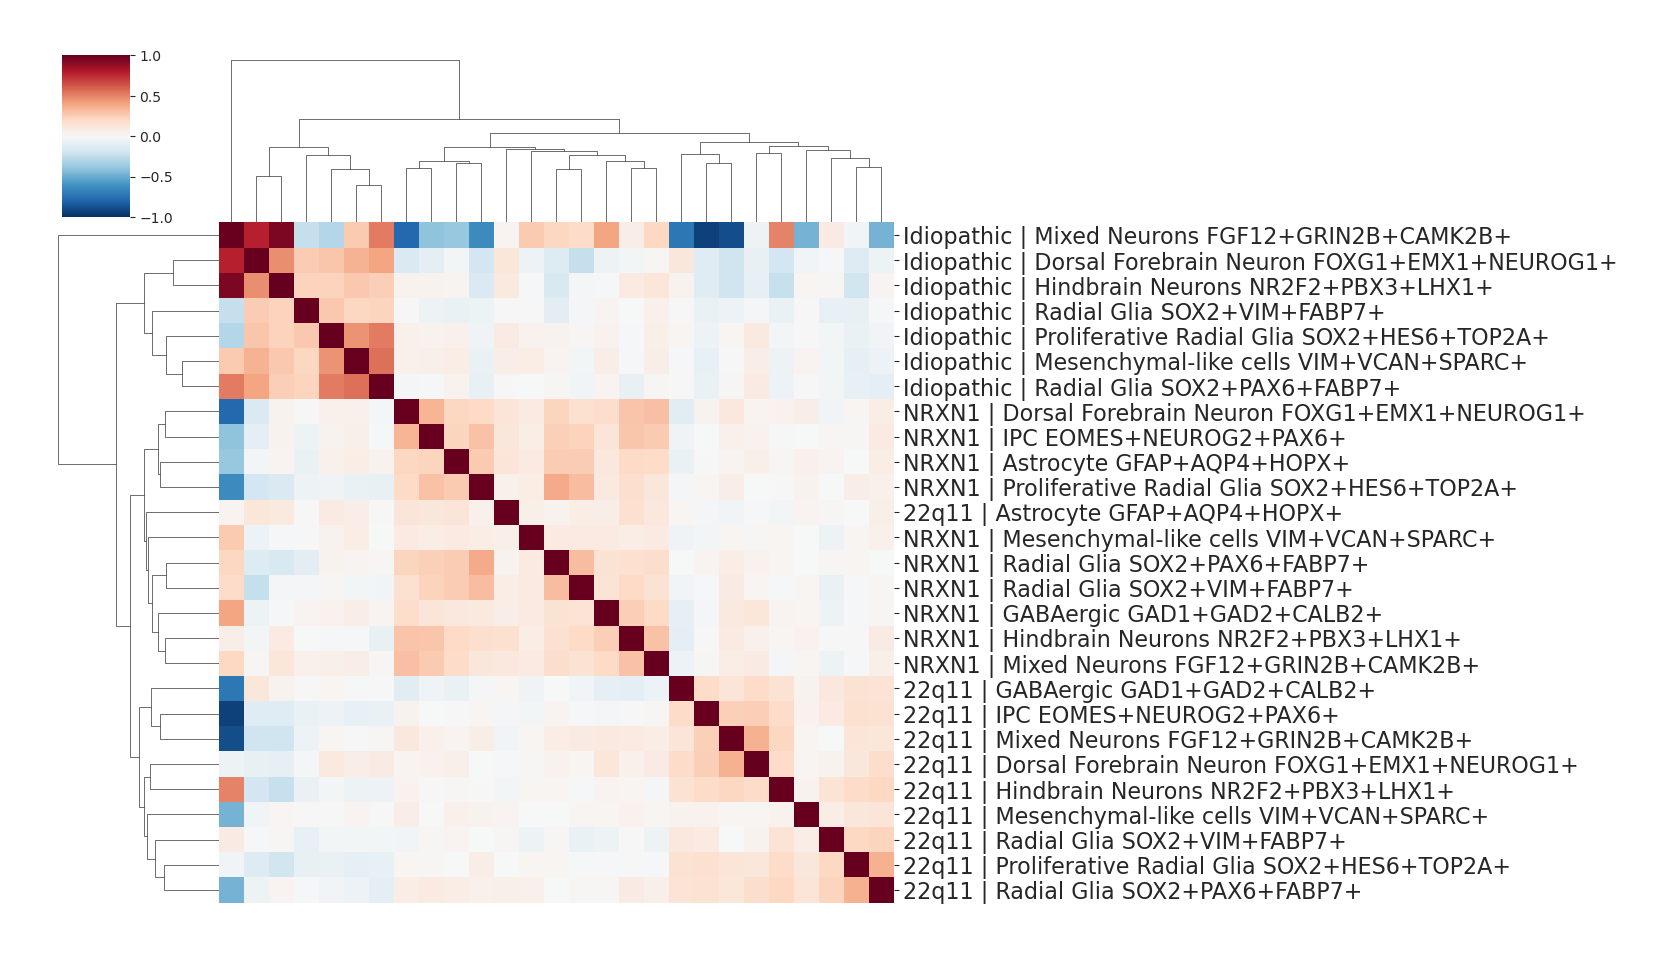

In [80]:
## Make Disease Specific Clustermap ##

idiopathic_mat = dge_idiopathic.pivot_table(index='assay', columns='ID', values='estimate')
idiopathic_mat.index = 'Idiopathic | ' + idiopathic_mat.index

x22q11_mat = dge_22q11.pivot_table(index='assay', columns='ID', values='estimate')
x22q11_mat.index = '22q11 | ' + x22q11_mat.index

nrxn1_mat = dge_nrxn1.pivot_table(index='assay', columns='ID', values='estimate')
nrxn1_mat.index = 'NRXN1 | ' + nrxn1_mat.index

all_dx_celltype = pd.concat([idiopathic_mat, x22q11_mat, nrxn1_mat], axis=0)


g = sns.clustermap(
    all_dx_celltype.T.corr(),
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    figsize=(13.5, 9),  
    xticklabels=False)

g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.tick_params(axis='y', labelsize=16)

# save figure
g.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_celltype_clustermap.svg",
          dpi=300, bbox_inches='tight')

In [74]:
corr = all_dx_celltype.T.corr()

records = []

for row in corr.index:
    for col in corr.columns:

        # avoid duplicates + self correlations
        if row >= col:
            continue

        disease1 = row.split(' | ')[0]
        disease2 = col.split(' | ')[0]

        records.append({
            'disease': disease1,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

        records.append({
            'disease': disease2,
            'comparison': (
                'within'
                if disease1 == disease2
                else 'outside'
            ),
            'correlation': corr.loc[row, col]
        })

plot_df = pd.DataFrame(records)

/tmp/ipykernel_22958/806530161.py:12: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


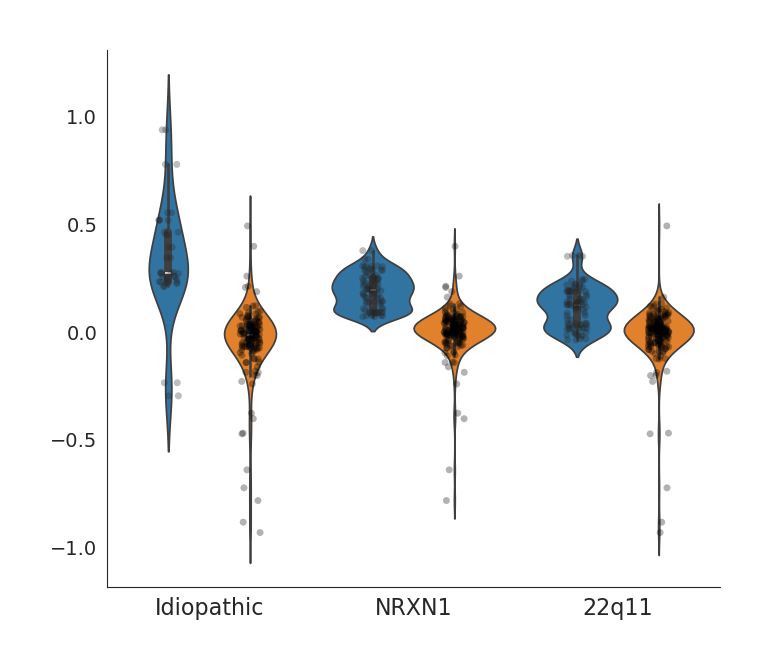

In [79]:
plt.figure(figsize=(7, 6))

sns.set_style("white")  # despine-friendly style

ax = sns.violinplot(
    data=plot_df,
    x='disease',
    y='correlation',
    hue='comparison'
)

sns.stripplot(
    data=plot_df,
    x='disease',
    y='correlation',
    hue='comparison',
    dodge=True,
    alpha=0.3,
    color='black'
)

# remove duplicate legend
ax.legend_.remove()

# despine
sns.despine()

# remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# control tick label font sizes
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=14)


plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Fig_Disease_Sig_celltype_violins.svg", dpi=500, bbox_inches='tight')
plt.tight_layout()

In [78]:
# run t-tests within each disease
results = []

for disease in plot_df['disease'].unique():
    
    sub = plot_df[plot_df['disease'] == disease]
    
    groups = sub['comparison'].unique()
    
    if len(groups) != 2:
        continue
    
    g1 = sub[sub['comparison'] == groups[0]]['correlation']
    g2 = sub[sub['comparison'] == groups[1]]['correlation']
    
    stat, pval = ttest_ind(g1, g2, equal_var=False)  # Welch t-test
    
    results.append({
        'disease': disease,
        'group1': groups[0],
        'group2': groups[1],
        't_stat': stat,
        'p_value': pval
    })

results_df = pd.DataFrame(results)

results_df

,disease,group1,group2,t_stat,p_value
0,Idiopathic,within,outside,8.376915,2.638630e-11
1,NRXN1,outside,within,-15.153202,8.940290e-37
2,22q11,outside,within,-8.801027,2.462197e-16
